Enhanced folder created successfully

Processing: aligatorCracking_1_frame_240.jpg
Before Sharpness: 138.61368910107186
Before Edge Strength: 41.10162574741117
Detected Type: Sharp
After Sharpness: 138.61368910107186
After Edge Strength: 41.10162574741117


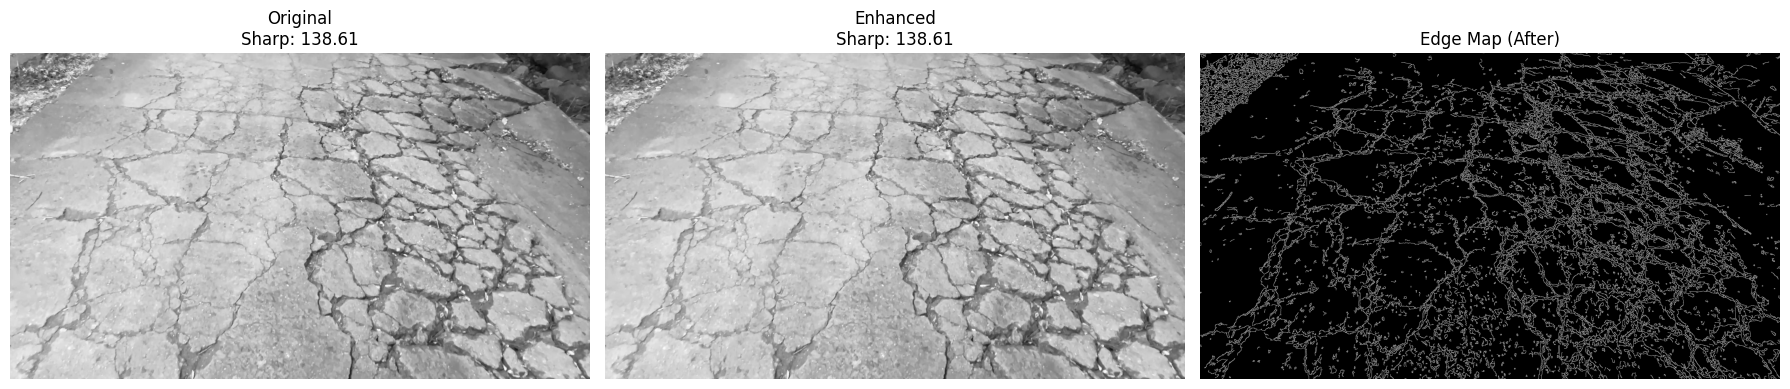


Processing: aligatorCracking_1_frame_245.jpg
Before Sharpness: 131.8521261862921
Before Edge Strength: 40.806885161561404
Detected Type: Sharp
After Sharpness: 131.8521261862921
After Edge Strength: 40.806885161561404


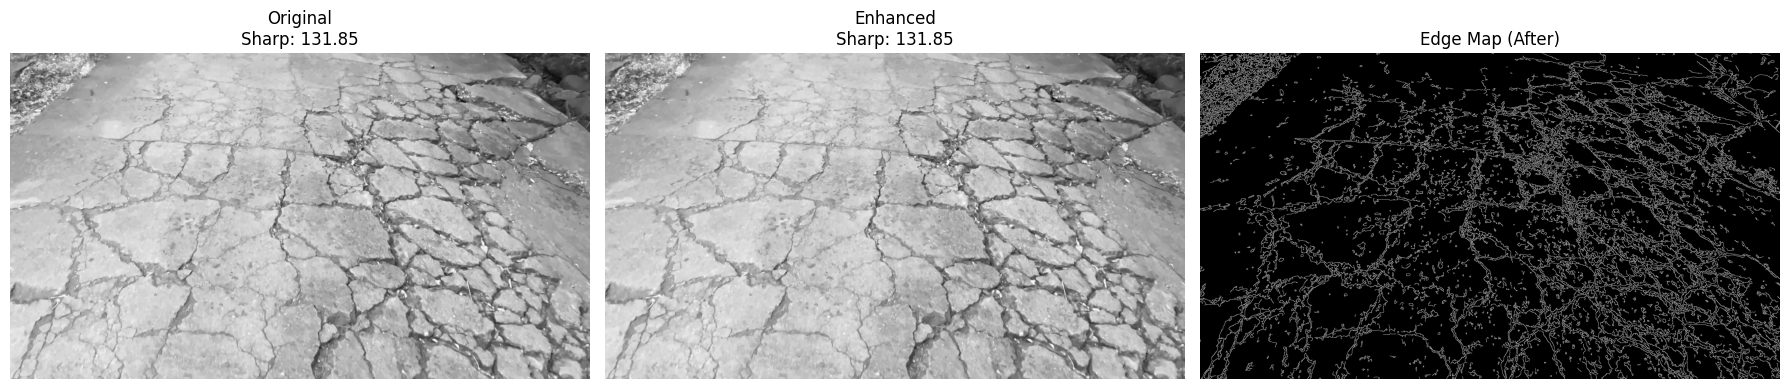


Processing: aligatorCracking_1_frame_250.jpg
Before Sharpness: 121.92827393275807
Before Edge Strength: 39.10843152238307
Detected Type: Sharp
After Sharpness: 121.92827393275807
After Edge Strength: 39.10843152238307


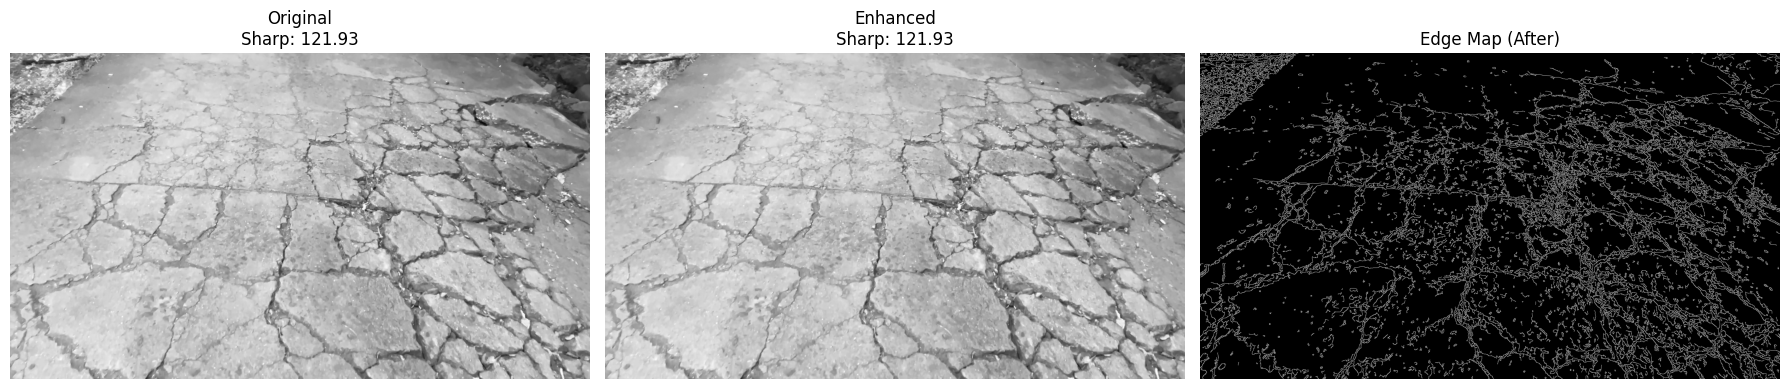


All images processed successfully!


In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Input and output folders
input_folder = "../frames/selected"
output_folder = "../frames/enhanced"
os.makedirs(output_folder, exist_ok=True)

print("Enhanced folder created successfully")

# Sharpness (Laplacian)
def calculate_sharpness(img):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(img, cv2.CV_64F).var()

# Edge Strength (Sobel)
def calculate_edge_strength(img):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(sobelx**2 + sobely**2)
    return np.mean(magnitude)

# Blur Detection
def detect_blur_type(sharpness, edge_strength):

    if sharpness < 60:
        return "Strong Blur"
    elif sharpness < 120:
        return "Moderate Blur"
    elif edge_strength < 25:
        return "Edge Loss"
    else:
        return "Sharp"

# Enhancement Methods
def enhance_image(img, blur_type):

    if blur_type == "Strong Blur":
        # Wiener-like smoothing + sharpening combo
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        enhanced = cv2.addWeighted(img, 1.5, blur, -0.5, 0)

    elif blur_type == "Moderate Blur":
        kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
        enhanced = cv2.filter2D(img, -1, kernel)

    elif blur_type == "Edge Loss":
        enhanced = cv2.Canny(img, 50, 150)

    else:
        enhanced = img.copy()

    return enhanced

# Get images
image_files = []
for file in os.listdir(input_folder):
    if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        image_files.append(file)

image_files = image_files[:3]  # only first 3 images

# Process each image
for filename in image_files:

    path = os.path.join(input_folder, filename)
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Failed to load:", filename)
        continue

    print("\n==============================")
    print("Processing:", filename)

    # Before
    sharp_before = calculate_sharpness(image)
    edge_before = calculate_edge_strength(image)

    print("Before Sharpness:", sharp_before)
    print("Before Edge Strength:", edge_before)

    # Classify
    blur_type = detect_blur_type(sharp_before, edge_before)
    print("Detected Type:", blur_type)

    # Enhance
    enhanced = enhance_image(image, blur_type)

    # After
    sharp_after = calculate_sharpness(enhanced)
    edge_after = calculate_edge_strength(enhanced)

    print("After Sharpness:", sharp_after)
    print("After Edge Strength:", edge_after)

    # Save
    save_path = os.path.join(output_folder, "enhanced_" + filename)
    cv2.imwrite(save_path, enhanced)

    # Image Comparison
    edges_original = cv2.Canny(image, 50, 150)
    edges_enhanced = cv2.Canny(enhanced, 50, 150)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original\nSharp: {sharp_before:.2f}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(enhanced, cmap='gray')
    plt.title(f"Enhanced\nSharp: {sharp_after:.2f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(edges_enhanced, cmap='gray')
    plt.title("Edge Map (After)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\nAll images processed successfully!")